# Testing and Training

## Testing QPBL

In [1]:
import sys
sys.path.append('../')

In [3]:
import pennylane as qml
from pennylane import numpy as np
from tensorflow.keras.datasets import mnist
from matplotlib import pyplot as plt
from scipy.linalg import expm
from random import sample as smp
#from qpbl.QPBL import Eigen, Utils, Mottonen


In [5]:
from pennylane.operation import Operation#, AnyWires


class Eigen(Operation):
    #num_wires = AnyWires
    #num_params = 6

    def __init__(self, theta: np.ndarray , wire = None, IndexQubits: int = 2, LQubits: int = 5, QQubits: int = 2, O : np.ndarray = None, T : str = "X"):
        self._hyperparameters = {
            "IndexQubits": IndexQubits,
            "LQubits": LQubits,
            "QQubits": QQubits,
            "O": O ,
            "T": T,
        }
        super().__init__(theta,wires=wire)
    
    @staticmethod
    def compute_decomposition(theta: np.ndarray, wires, IndexQubits: int, LQubits: int = 5, QQubits: int = 2, O : np.ndarray = None, T : str = "X") -> list[Operation]:
        """Compute the decomposition of the Eigen operation."""
        n_params = 0 #len(theta) Temporaly there is not going to be training by
        offset_L = n_params + IndexQubits
        offset_U = n_params + IndexQubits + LQubits
        n_qubits = n_params + IndexQubits + LQubits + QQubits
        op_list = []
        for i in range(LQubits):
            op_list.append(qml.Hadamard(wires=i+offset_L))
        for i in range(LQubits):
            op_list.append(qml.ctrl(qml.QubitUnitary(Utils.powm(O,i), wires=range(offset_U,n_qubits)), control=offset_U-1-i))
        op_list.append(qml.adjoint(qml.QFT(wires=range(offset_L, offset_U))))
        
        return op_list

class Mottonen(Operation):
    num_wires = AnyWires
    
    def __init__(self, theta: np.ndarray , wire = None, QQubits: int =2, offset_U: int = 5):
        self._hyperparameters = {
            "QQubits": QQubits,
            "offset_U": offset_U,
        }
        super().__init__(theta,wires=wire)
    
    @staticmethod
    def compute_decomposition(theta: np.ndarray, wires, QQubits: int = 2,  offset_U: int = 5) -> list[Operation]:
        op_list = []
        c = 2**QQubits -2
        for k,i in enumerate(range(QQubits-1, -1, -1)):
            for j in range(2**k-1,-1,-1):
                if k>0:
                    op_list.append(qml.ctrl(qml.adjoint(qml.RY(theta[c], wires=k+offset_U)), control=range(offset_U,k+offset_U), control_values=Utils.int_to_bin(j,k)))
                else:
                    op_list.append(qml.adjoint(qml.RY(theta[c], wires=k+QQubits)))
                c = c - 1
        return op_list

class Utils():

    def __init__(self):
        pass

    @staticmethod
    def int_to_bin(n, num_bits)-> tuple:
        return tuple(int(x) for x in format(n, f'0{num_bits}b'))
    
    @staticmethod
    def powm(M,p):
        if p == 0:
            return M
        T = M@M
        for i in range(1,p):
            T = T@T
        return T

## Loading Data

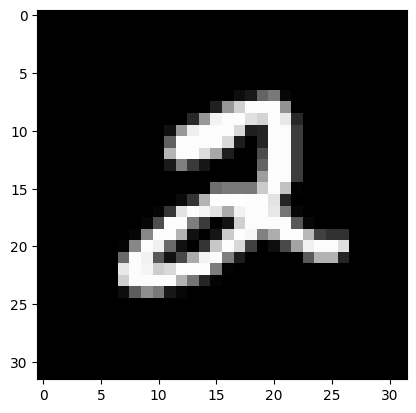

In [6]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train_n = x_train[y_train == 2]
x_train_n_32 = np.pad(x_train_n, ((0, 0), (2, 2), (2, 2)), mode='constant', constant_values=0)
Image = x_train_n_32[0]

plt.imshow(Image, cmap='gray')
plt.show()

In [7]:
Img_O = np.zeros_like(x_train_n_32, dtype=complex)

for (i,img) in enumerate(x_train_n_32):
    I = np.cov(img/255.0)
    Img_O[i] = expm(1j * I)

### Simple test

First test of the **Eigen** class without superposition

In [6]:
IQubits = 0
PQubits = 0
LQubits = 5
QQubits = 5
offsetL = PQubits + IQubits
offsetQ = PQubits + IQubits + LQubits
nQubits = IQubits + PQubits + LQubits + QQubits

In [82]:
dev = qml.device('default.qubit', wires=10)
@qml.qnode(dev)
def circuit(theta,Operator):
    # Proyector |1><1|
    P1 = np.array([[0,0],[0,1]])
    for i in range(offsetQ,nQubits):
        qml.Hadamard(wires=i)
    qml.Barrier()
    Eigen(theta=theta, wire=range(nQubits), IndexQubits=IQubits, LQubits=LQubits, QQubits=QQubits, O=Operator)#,wires=range(nQubits))
    H = np.kron(P1,np.eye(2**(QQubits -1)))
    return qml.expval(qml.Hermitian(H,wires=range(offsetL,offsetQ)))

In [83]:
f = qml.qnode(dev)(circuit)

(<Figure size 600x1200 with 1 Axes>, <Axes: >)


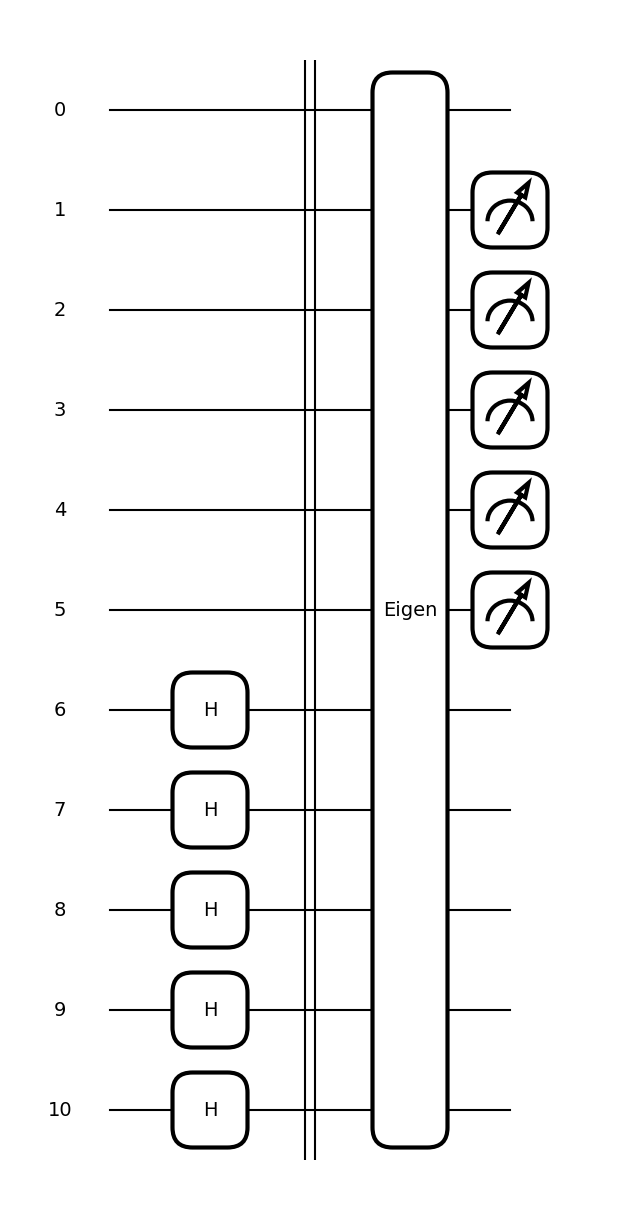

In [84]:
print(qml.draw_mpl(circuit)([0.5], Img_O[0]))

In [85]:
f([], Img_O[0])

WireError: Cannot run circuit(s) on default.qubit as they contain wires not found on the device: {10}

### More complicated test using superposition

In [55]:
IQubits = 7
PQubits = 0
LQubits = 5
QQubits = 5
offsetL = PQubits + IQubits
offsetQ = PQubits + IQubits + LQubits
nQubits = IQubits + PQubits + LQubits + QQubits
dev2 = qml.device('default.qubit', wires=nQubits)
@qml.qnode(dev2)
def circuitS(theta,Operator, AllExplorers=True):
    # Proyector |1><1|
    for i in range(IQubits):
        qml.Hadamard(wires=i)
    P1 = np.array([[0,0],[0,1]])
    if AllExplorers:
        for i in range(offsetQ,nQubits):
            qml.Hadamard(wires=i)
    qml.Barrier()
    if IQubits>0:
        for i in range(2**IQubits):
            qml.ctrl(
                Eigen(theta=theta, wire=range(offsetL,nQubits), IndexQubits=IQubits, LQubits=LQubits, QQubits=QQubits, O=Operator[i]),
                    control=range(IQubits), control_values=Utils.int_to_bin(n=i, num_bits=IQubits))
    else:
        Eigen(theta=theta, wire=range(offsetL,nQubits), IndexQubits=IQubits, LQubits=LQubits, QQubits=QQubits, O=Operator[0])
    H = np.kron(P1,np.eye(2**(QQubits -1)))
    return qml.expval(qml.Hermitian(H,wires=range(offsetL,offsetQ)))

In [53]:
c = qml.QNode(circuitS,dev2)
#print(qml.draw_mpl(c)([], Img_O[:2**IQubits]))

In [54]:
l = c([], Img_O[:2**IQubits])
print(l)

0.009745803179182222


In [37]:
Img_O.shape

(5958, 32, 32)

### Test for difernt number of images

#### With explorers

- 0.010447079607649542
- 0.00908941821650146
- 0.005273773861057132
- 0.007346519362306848
- 0.009405176215222667
- 0.009869724648894964
- 0.009745803179182222

#### Without explorers

- 3.6684553641067426e-33
- 1.8284130934892636e-33
- 3.9687077991510686e-33
- 1.0348551951287324e-33
- 1.1778479734113156e-33
- 4.194413990576778e-33

In [56]:
num_test = 6
for i in range(num_test):
    IQubits = i
    PQubits = 0
    LQubits = 5
    QQubits = 5
    offsetL = PQubits + IQubits
    offsetQ = PQubits + IQubits + LQubits
    nQubits = IQubits + PQubits + LQubits + QQubits
    dev2 = qml.device('default.qubit', wires=nQubits)
    c = qml.QNode(circuitS,dev2)
    #print(qml.draw_mpl(c)([], Img_O[:2**IQubits]))
    l = c([], Img_O[:2**IQubits], False)
    print(l)


3.6684553641067426e-33
1.8284130934892636e-33
3.9687077991510686e-33
1.0348551951287324e-33
1.1778479734113156e-33
4.194413990576778e-33


## Trainig with Ansatz
### Testing first the Mottonen class

In [17]:
IQubits = 0
PQubits = 0
LQubits = 5
QQubits = 5
offsetL = PQubits + IQubits
offsetQ = PQubits + IQubits + LQubits
nQubits = IQubits + PQubits + LQubits + QQubits
dev2 = qml.device('default.qubit', wires=nQubits)
@qml.qnode(dev2)
def circuitM(theta,Operator):
    # Proyector |1><1|
    for i in range(IQubits):
        qml.Hadamard(wires=i)
    P1 = np.array([[0,0],[0,1]])
    for i in range(offsetQ,nQubits):
        qml.Hadamard(wires=i)
    Mottonen(theta,wire=range(offsetQ,nQubits),QQubits=QQubits, offset_U = offsetQ)
    qml.Barrier()
    if IQubits>0:
        for i in range(2**IQubits):
            qml.ctrl(
                Eigen(theta=theta, wire=range(offsetL,nQubits), IndexQubits=IQubits, LQubits=LQubits, QQubits=QQubits, O=Operator[i]),
                    control=range(IQubits), control_values=Utils.int_to_bin(n=i, num_bits=IQubits))
    else:
        Eigen(theta=theta, wire=range(offsetL,nQubits), IndexQubits=IQubits, LQubits=LQubits, QQubits=QQubits, O=Operator[0])
    H = np.kron(P1,np.eye(2**(QQubits -1)))
    return qml.expval(qml.Hermitian(H,wires=range(offsetL,offsetQ)))

(<Figure size 700x1100 with 1 Axes>, <Axes: >)


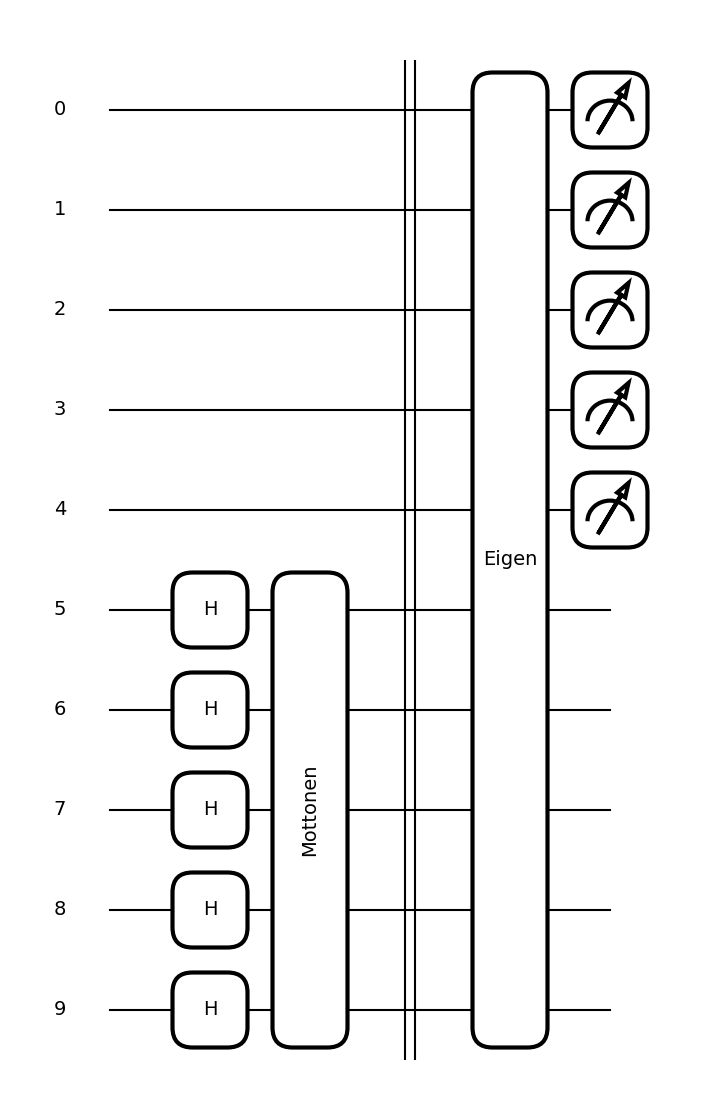

In [18]:
CM = qml.QNode(circuitM,dev2)
theta = np.random.uniform(0,np.pi,size=2**QQubits-1)
theta_2 = np.zeros_like(theta)
print(qml.draw_mpl(CM)(theta_2,Img_O[:2**IQubits]))

In [20]:
l = CM(theta_2,Img_O[:2**IQubits])
print(l)

0.010447079607649542


### Now testing the training

In [8]:
IQubits = 5
PQubits = 0
LQubits = 5
QQubits = 5
offsetL = PQubits + IQubits
offsetQ = PQubits + IQubits + LQubits
nQubits = IQubits + PQubits + LQubits + QQubits
dev2 = qml.device('default.qubit', wires=nQubits) #lightning.gpu, default.qubit.tf
#dev2 = qml.device('qulacs.simulator', wires=nQubits) 
num_layers = 1

@qml.qnode(dev2)
def circuitM(theta,Operator, AllExplorers=True):
    # Proyector |1><1|
    for i in range(IQubits):
        qml.Hadamard(wires=i)
    P1 = np.array([[0,0],[0,1]])
    if AllExplorers:
        for i in range(offsetQ,nQubits):
            qml.Hadamard(wires=i)
    # Multilayer
    for i in range(num_layers):
        Mottonen(theta[i],wire=range(offsetQ,nQubits),QQubits=QQubits, offset_U = offsetQ)
    qml.Barrier()
    if IQubits>0:
        for i in range(2**IQubits):
            qml.ctrl(
                Eigen(theta=theta, wire=range(offsetL,nQubits), IndexQubits=IQubits, LQubits=LQubits, QQubits=QQubits, O=Operator[i]),
                    control=range(IQubits), control_values=Utils.int_to_bin(n=i, num_bits=IQubits))
    else:
        Eigen(theta=theta, wire=range(offsetL,nQubits), IndexQubits=IQubits, LQubits=LQubits, QQubits=QQubits, O=Operator[0])
    H = np.kron(P1,np.eye(2**(QQubits -1)))
    return qml.expval(qml.Hermitian(H,wires=range(offsetL,offsetQ)))

In [9]:
CM = qml.QNode(circuitM,dev2)
#theta = np.random.uniform(0,np.pi,size=2**QQubits-1)
#theta_2 = np.zeros_like(theta)
#print(qml.draw_mpl(CM)(theta_2,Img_O[:2**IQubits]))

In [10]:
def loss_MSE(weights,O, opt):
    """Computes the cost over the provided features and labels"""
    preds = circuitM(weights, O, opt)
    return (np.tensor(1.00)-preds) ** 2

In [11]:
def train(image_data_train, iter=20, lr=0.1, opt = True, randonmized=False):
    weights = np.array(np.random.uniform(0,np.pi,size=(num_layers,2**QQubits -1)), requires_grad=True) # initialize weights
    opt = qml.GradientDescentOptimizer(stepsize=lr) # gradient optimizer
    if randonmized:
        img_idxs = smp(range(len(image_data_train)),2**IQubits)
        image_data_train_2 = image_data_train[img_idxs]
    else:
        image_data_train_2 = image_data_train[:2**IQubits]
    for i in range(iter):
        weights, loss = opt.step_and_cost(lambda w: loss_MSE(w, image_data_train_2, opt), weights)
        #if i % 50 == 0:
        print(f"Epoch {i+1}, {loss}:")
    return weights

In [27]:
trained_weights = train(Img_O[:2**IQubits], iter=10000, lr=0.3)

Epoch 1, 0.9621056269104874:
Epoch 51, 0.25624238592352866:
Epoch 101, 0.25445292608990494:
Epoch 151, 0.25441795448597293:
Epoch 201, 0.2543838467121971:
Epoch 251, 0.25434973929289745:
Epoch 301, 0.2543156443050744:
Epoch 351, 0.2542815741186623:
Epoch 401, 0.2542475409342011:
Epoch 451, 0.25421355675863927:
Epoch 501, 0.25417963338264554:
Epoch 551, 0.2541457823593104:
Epoch 601, 0.254112014984314:
Epoch 651, 0.25407834227762555:
Epoch 701, 0.2540447749667937:
Epoch 751, 0.2540113234718628:
Epoch 801, 0.2539779978919519:
Epoch 851, 0.25394480799350616:
Epoch 901, 0.25391176320022874:
Epoch 951, 0.25387887258468533:
Epoch 1001, 0.2538461448615604:
Epoch 1051, 0.25381358838253754:
Epoch 1101, 0.2537812111327624:
Epoch 1151, 0.25374902072884054:
Epoch 1201, 0.25371702441830934:
Epoch 1251, 0.2536852290805221:
Epoch 1301, 0.25365364122887046:
Epoch 1351, 0.2536222670142655:
Epoch 1401, 0.25359111222979674:
Epoch 1451, 0.253560182316482:
Epoch 1501, 0.25352948237001377:
Epoch 1551, 0.253

In [28]:
l=CM(trained_weights,Img_O[:2**IQubits],True)
print(l)

0.49854413899445227


In [33]:
trained_weights2 = train(Img_O[:2**IQubits], iter=100, lr=0.3)

Epoch 1, 0.6019907096617375:
Epoch 2, 0.5631077851123135:
Epoch 3, 0.5265975485268612:
Epoch 4, 0.49306482053583783:
Epoch 5, 0.46282983688785007:
Epoch 6, 0.4359697646154544:
Epoch 7, 0.4123810360139096:
Epoch 8, 0.39184319480861:
Epoch 9, 0.37407281160132994:
Epoch 10, 0.3587633359127646:
Epoch 11, 0.34561144408729744:
Epoch 12, 0.3343325596692418:
Epoch 13, 0.32466864154350517:
Epoch 14, 0.31639092529199947:
Epoch 15, 0.30929963759741813:
Epoch 16, 0.30322206929598833:
Epoch 17, 0.2980098930059494:
Epoch 18, 0.293536256653633:
Epoch 19, 0.28969294952114794:
Epoch 20, 0.2863877902786468:
Epoch 21, 0.28354229861745395:
Epoch 22, 0.28108966240899774:
Epoch 23, 0.2789729861717751:
Epoch 24, 0.2771437944734105:
Epoch 25, 0.27556075970686567:
Epoch 26, 0.2741886237873605:
Epoch 27, 0.27299728554726:
Epoch 28, 0.27196102871734834:
Epoch 29, 0.2710578686938785:
Epoch 30, 0.27026899945266775:
Epoch 31, 0.26957832482567606:
Epoch 32, 0.26897206084884523:
Epoch 33, 0.2684383980247207:
Epoch 34

In [38]:
trained_weights3 = train(Img_O[:2**IQubits], iter=100, lr=0.3)

Epoch 1, 0.3370330471756086:
Epoch 2, 0.3280079765963677:
Epoch 3, 0.3202918719474868:
Epoch 4, 0.31369358381652673:
Epoch 5, 0.30804859936271545:
Epoch 6, 0.30321609471574723:
Epoch 7, 0.2990759310415526:
Epoch 8, 0.2955258184778838:
Epoch 9, 0.29247875193342937:
Epoch 10, 0.2898607530091479:
Epoch 11, 0.2876089142517977:
Epoch 12, 0.28566972302598087:
Epoch 13, 0.28399763446336623:
Epoch 14, 0.2825538612598426:
Epoch 15, 0.28130534957612713:
Epoch 16, 0.2802239132340701:
Epoch 17, 0.27928550182873396:
Epoch 18, 0.27846958178678466:
Epoch 19, 0.277758612548667:
Epoch 20, 0.2771376028366877:
Epoch 21, 0.27659373437402807:
Epoch 22, 0.276116042461235:
Epoch 23, 0.2756951445345987:
Epoch 24, 0.275323009268224:
Epoch 25, 0.27499275998055356:
Epoch 26, 0.2746985071050169:
Epoch 27, 0.27443520531670323:
Epoch 28, 0.2741985316009033:
Epoch 29, 0.27398478112887786:
Epoch 30, 0.27379077829095594:
Epoch 31, 0.2736138006433949:
Epoch 32, 0.27345151386668143:
Epoch 33, 0.2733019161201441:
Epoch 3

In [44]:
l = CM(trained_weights3,Img_O[:2**IQubits],False)
print(l)

0.4923890296309372


In [42]:
trained_weights4 = train(Img_O[:2**IQubits], iter=100, lr=0.3, opt = False)

Epoch 1, 0.8833961912845933:
Epoch 2, 0.8583969353831831:
Epoch 3, 0.8293997803265255:
Epoch 4, 0.7965499459625369:
Epoch 5, 0.7603046142475623:
Epoch 6, 0.721439983539122:
Epoch 7, 0.6809950414370907:
Epoch 8, 0.6401551543575074:
Epoch 9, 0.600101960607027:
Epoch 10, 0.561870131437674:
Epoch 11, 0.5262474226261111:
Epoch 12, 0.4937350298255832:
Epoch 13, 0.4645627892660806:
Epoch 14, 0.43873962664056926:
Epoch 15, 0.41611724597032407:
Epoch 16, 0.39645062584653856:
Epoch 17, 0.3794467559000053:
Epoch 18, 0.36479940023876795:
Epoch 19, 0.3522113437330981:
Epoch 20, 0.34140699577613703:
Epoch 21, 0.33213829685649754:
Epoch 22, 0.32418635313558314:
Epoch 23, 0.31736056902412174:
Epoch 24, 0.31149646755011484:
Epoch 25, 0.30645294717384286:
Epoch 26, 0.30210941715979633:
Epoch 27, 0.2983630535724791:
Epoch 28, 0.29512629388980627:
Epoch 29, 0.2923246149110106:
Epoch 30, 0.28989459766135056:
Epoch 31, 0.28778226183841243:
Epoch 32, 0.2859416428807068:
Epoch 33, 0.28433358188472846:
Epoch 3

In [45]:
l = CM(trained_weights4,Img_O[:2**IQubits],False)
print(l)

0.48473077076883164


In [13]:
trained_weights5 = train(Img_O[:2**IQubits], iter=100, lr=0.3, opt = True)

Epoch 1, 0.3924446538639953:
Epoch 2, 0.3773283328525723:
Epoch 3, 0.36430936240200024:
Epoch 4, 0.35311760750021337:
Epoch 5, 0.34350652133173054:
Epoch 6, 0.33525621426597824:
Epoch 7, 0.32817361283072244:
Epoch 8, 0.3220909808461336:
Epoch 9, 0.3168636352770537:
Epoch 10, 0.31236736972414136:
Epoch 11, 0.30849588197462746:
Epoch 12, 0.3051583630075345:
Epoch 13, 0.30227731962111626:
Epoch 14, 0.2997866530419348:
Epoch 15, 0.2976299884483202:
Epoch 16, 0.2957592365573174:
Epoch 17, 0.2941333626556233:
Epoch 18, 0.292717337189669:
Epoch 19, 0.2914812431376669:
Epoch 20, 0.29039951761220956:
Epoch 21, 0.2894503077719529:
Epoch 22, 0.28861492376803327:
Epoch 23, 0.2878773739211659:
Epoch 24, 0.28722396953547935:
Epoch 25, 0.2866429886828733:
Epoch 26, 0.28612438994664224:
Epoch 27, 0.2856595685198129:
Epoch 28, 0.28524114824204666:
Epoch 29, 0.28486280415944776:
Epoch 30, 0.2845191110324206:
Epoch 31, 0.28420541392298954:
Epoch 32, 0.2839177175864274:
Epoch 33, 0.2836525918911023:
Epoch

In [ ]:
trained_weights6 = train(Img_O[:2**IQubits], iter=100, lr=0.3, opt = False)

Epoch 1, 0.320875176780394:
Epoch 2, 0.31959968443737585:
Epoch 3, 0.31838860100020105:
Epoch 4, 0.31723563751441775:
Epoch 5, 0.3161353099977069:
Epoch 6, 0.31508283094643397:
Epoch 7, 0.3140740154330904:
Epoch 8, 0.31310519986238944:
Epoch 9, 0.3121731717026628:
Epoch 10, 0.31127510872789443:
Epoch 11, 0.3104085264973172:
Epoch 12, 0.30957123296692907:
Epoch 13, 0.3087612892733771:
Epoch 14, 0.3079769758579026:
Epoch 15, 0.3072167632087946:
Epoch 16, 0.3064792865970726:
Epoch 17, 0.3057633242637734:
Epoch 18, 0.3050677785898359:
Epoch 19, 0.3043916598426106:
Epoch 20, 0.30373407214768544:
Epoch 21, 0.3030942013821093:
Epoch 22, 0.3024713047261939:
Epoch 23, 0.3018647016466469:
Epoch 24, 0.30127376611463524:
Epoch 25, 0.3006979198890595:
Epoch 26, 0.30013662671843405:
Epoch 27, 0.29958938733475593:
Epoch 28, 0.2990557351300484:
Epoch 29, 0.2985352324212231:
Epoch 30, 0.2980274672218419:
Epoch 31, 0.29753205045053427:
Epoch 32, 0.29704861351549816:
Epoch 33, 0.2965768062228472:
Epoch 3

In [12]:
trained_weights7 = train(Img_O[:2**IQubits], iter=50, lr=0.3, opt = True)

Epoch 1, 0.3741926947696614:
Epoch 2, 0.35051367607497735:
Epoch 3, 0.333200034691687:
Epoch 4, 0.32053747228890217:
Epoch 5, 0.31124077990462645:
Epoch 6, 0.3043726370464919:
Epoch 7, 0.29925713328875553:
Epoch 8, 0.2954085795299865:
Epoch 9, 0.2924779689990486:
Epoch 10, 0.2902141502998678:
Epoch 11, 0.2884360545184153:
Epoch 12, 0.2870129002816168:
Epoch 13, 0.28585007261858747:
Epoch 14, 0.28487902337609894:
Epoch 15, 0.2840500265623252:
Epoch 16, 0.28332696735640306:
Epoch 17, 0.282683585245935:
Epoch 18, 0.28210076051731847:
Epoch 19, 0.2815645515503203:
Epoch 20, 0.2810647736576958:
Epoch 21, 0.28059396923742724:
Epoch 22, 0.28014666106473823:
Epoch 23, 0.2797188106581448:
Epoch 24, 0.27930742528453145:
Epoch 25, 0.2789102727535369:
Epoch 26, 0.2785256744054323:
Epoch 27, 0.278152354836067:
Epoch 28, 0.27778933279625495:
Epoch 29, 0.27743584197431953:
Epoch 30, 0.27709127346792306:
Epoch 31, 0.2767551339983257:
Epoch 32, 0.2764270155507631:
Epoch 33, 0.27610657330805577:
Epoch 3

In [16]:
trained_weights8 = train(Img_O[:2**IQubits], iter=50, lr=0.3, opt = True)

Epoch 1, 0.5510002819264981:
Epoch 2, 0.49699400143855693:
Epoch 3, 0.4562085532651678:
Epoch 4, 0.4262571224997495:
Epoch 5, 0.40427474699858307:
Epoch 6, 0.3878430352982871:
Epoch 7, 0.3751852075585771:
Epoch 8, 0.3650788670440395:
Epoch 9, 0.35671065545477953:
Epoch 10, 0.3495487964888812:
Epoch 11, 0.3432486462011957:
Epoch 12, 0.33758745123306977:
Epoch 13, 0.33242083749811174:
Epoch 14, 0.32765436880914733:
Epoch 15, 0.32322519939369554:
Epoch 16, 0.31909035467884356:
Epoch 17, 0.3152193087011287:
Epoch 18, 0.31158932003147594:
Epoch 19, 0.30818252449962064:
Epoch 20, 0.3049841384693597:
Epoch 21, 0.3019813589568243:
Epoch 22, 0.29916269756986336:
Epoch 23, 0.29651758214219326:
Epoch 24, 0.2940361218267704:
Epoch 25, 0.29170897070266666:
Epoch 26, 0.2895272497457193:
Epoch 27, 0.28748250257087554:
Epoch 28, 0.2855666700562631:
Epoch 29, 0.2837720749695477:
Epoch 30, 0.28209141141231747:
Epoch 31, 0.2805177361489599:
Epoch 32, 0.2790444602410039:
Epoch 33, 0.27766534020982647:
Epo

In [17]:
trained_weights8 = train(Img_O[:2**IQubits], iter=50, lr=0.3, opt = False)

Epoch 1, 0.9720713657022296:
Epoch 2, 0.9601728035297437:
Epoch 3, 0.9387416024238261:
Epoch 4, 0.9017125351477118:
Epoch 5, 0.8422248410161839:
Epoch 6, 0.7572667620930426:
Epoch 7, 0.654805103909962:
Epoch 8, 0.5540519694443912:
Epoch 9, 0.47254403583995286:
Epoch 10, 0.41527804424931447:
Epoch 11, 0.3779675415133034:
Epoch 12, 0.3543322878207118:
Epoch 13, 0.33938782653625926:
Epoch 14, 0.3298188381247725:
Epoch 15, 0.3235500804615804:
Epoch 16, 0.31930779164666745:
Epoch 17, 0.3163141120947745:
Epoch 18, 0.3140941792757378:
Epoch 19, 0.3123578231149129:
Epoch 20, 0.3109275155616667:
Epoch 21, 0.30969449955431766:
Epoch 22, 0.308592039561542:
Epoch 23, 0.30757908984617727:
Epoch 24, 0.3066303141336593:
Epoch 25, 0.30572998365562104:
Epoch 26, 0.30486824581766464:
Epoch 27, 0.3040388426401385:
Epoch 28, 0.3032377159709987:
Epoch 29, 0.3024621550721033:
Epoch 30, 0.30171027586652405:
Epoch 31, 0.30098070293491264:
Epoch 32, 0.3002723754099817:
Epoch 33, 0.2995844285530121:
Epoch 34, 0

In [40]:
# More Pictures and randomise
trained_weights9 = train(Img_O, iter=50, lr=0.3, opt = True)

Epoch 1, 0.9815695535325991:
Epoch 2, 0.9815319014721733:
Epoch 3, 0.9814941706116072:


KeyboardInterrupt: 

In [12]:
trained_weights10 = train(Img_O, iter=50, lr=0.3, opt = True, randonmized=False)

: 

: 

: 

### Test

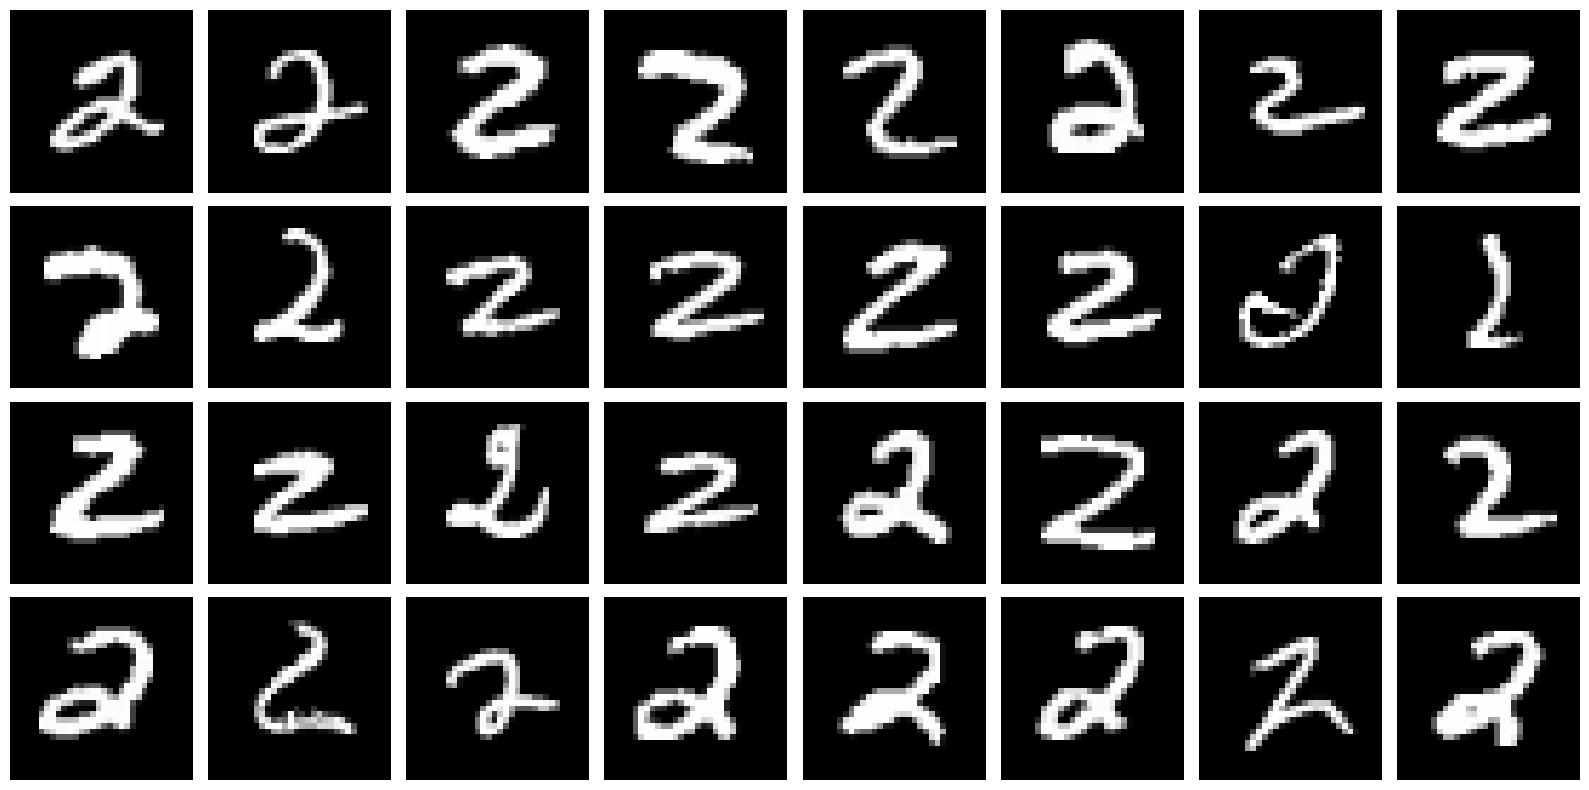

In [22]:
n_rows, n_cols = 4, 8
n_images = min(n_rows * n_cols, x_train_n_32.shape[0])

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))
for idx in range(n_rows * n_cols):
    r, c = divmod(idx, n_cols)
    ax = axes[r, c]
    if idx < n_images:
        ax.imshow(x_train_n_32[idx], cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

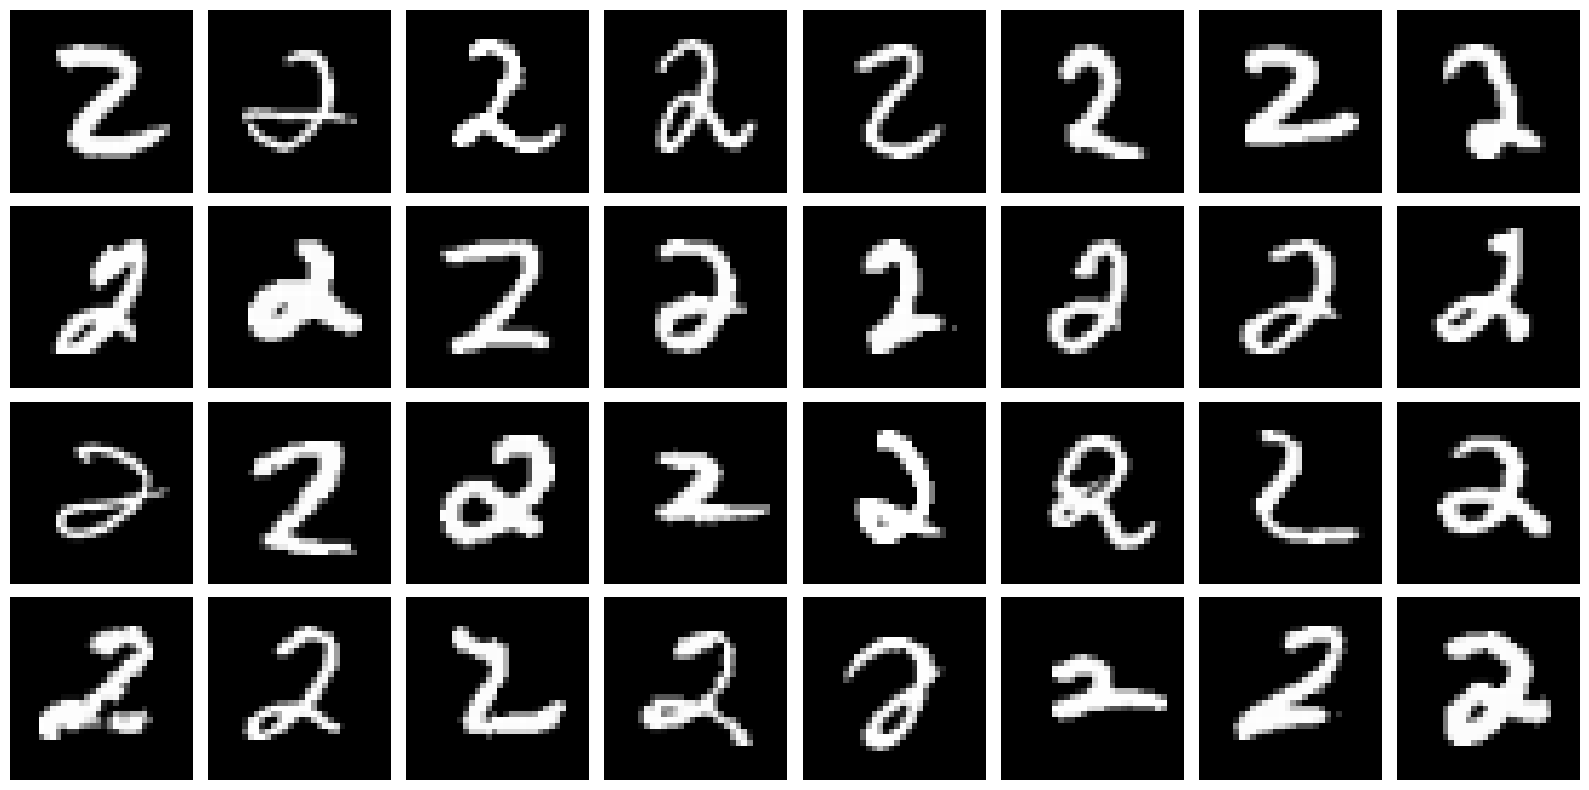

In [32]:
from random import sample as smp
n_rows, n_cols = 4, 8
n_images = min(n_rows * n_cols, x_train_n_32.shape[0])

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))

img_idxs = smp(range(len(x_train_n_32)),32)

for idx in range(n_rows * n_cols):
    r, c = divmod(idx, n_cols)
    ax = axes[r, c]
    
    if img_idxs[idx] < len(x_train_n_32):
        ax.imshow(x_train_n_32[img_idxs[idx]], cmap='gray')
        #print(img_idxs[idx])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [34]:
img_idxs = smp(range(len(x_train_n_32)),2**IQubits)
image_data_train_2 = x_train_n_32[img_idxs]

In [11]:
from pandas import DataFrame

In [12]:
Img_df = DataFrame(Img_O[0])
display(Img_df)

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,...,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
1,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,...,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
2,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,...,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
3,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,...,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
4,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,...,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
5,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,...,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
6,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,...,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
7,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.997606+0.010941j,-0.009270+0.024440j,-0.011052+0.019276j,...,0.001524-0.008466j,0.002682-0.005830j,0.001248-0.001306j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
8,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,-0.009270+0.024440j,0.961310+0.100264j,-0.047171+0.097708j,...,0.006202-0.038827j,0.010869-0.028701j,0.004592-0.006659j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
9,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,-0.011052+0.019276j,-0.047171+0.097708j,0.937536+0.133882j,...,0.000065-0.022214j,0.010650-0.037844j,0.005253-0.010153j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j


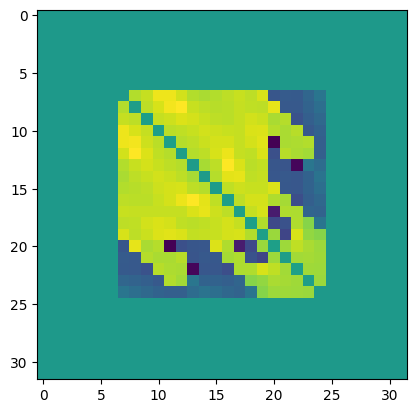

In [13]:
plt.imshow(np.angle(Img_O[0]))

In [14]:
n_qubits = 10
q_qubits = 5
l_qubits = 5
dev = qml.device("default.qubit", wires=n_qubits) #, shots=1000
@qml.qnode(dev)
def ImageEigen(theta, image, control_values=True):
    
    # Definition of the Proyector
    P1 = np.array([[0,0],[0,1]])

    # Optional Hadamards section
    if control_values:
        for i in range(l_qubits,n_qubits):
            qml.Hadamard(wires=i)
    # # Mottonen Ansatz
    # c = 2**q_qubits -2
    # for k,i in enumerate(range(q_qubits-1, -1, -1)):
    #     for j in range(2**k-1,-1,-1):
    #         if k>0:
    #             qml.ctrl(qml.adjoint(qml.RY(theta[c], wires=k+l_qubits)), control=range(l_qubits,k+l_qubits), control_values=int_to_bin(j,k))
    #         else:
    #             qml.adjoint(qml.RY(theta[c], wires=k+q_qubits))
    #         c = c - 1
    
    qml.Barrier()
    
    for i in range(5):
        qml.Hadamard(wires=i)
    qml.ControlledSequence(qml.QubitUnitary(image, wires=range(5,10)),control=range(5))
    qml.adjoint(qml.QFT(wires=range(5)))
    H = np.kron(P1,np.eye(2**(q_qubits -1)))
    return qml.expval(qml.Hermitian(H,wires=range(5)))

In [49]:
ImageEigen([], Img_O[0])

tensor(0.01044708, requires_grad=True)

In [50]:
dev = qml.device("default.qubit", wires=10) # shots=1000

def powm(M,p):
    if p == 0:
        return M
    T = M@M
    for i in range(1,p):
        T = T@T
    return T

@qml.qnode(dev)
def ImageEigen2(image, option=True):
    P1 = np.array([[0,0],[0,1]])
    for i in range(5):
        qml.Hadamard(wires=i)
    for i in range(5,10):
        qml.Hadamard(wires=i)
    for i in range(5):
        qml.ctrl(qml.QubitUnitary(powm(image,i), wires=range(5,10)), control=4-i)
    qml.adjoint(qml.QFT(wires=range(5)))
    H = np.kron(P1,np.eye(2**4))
    #if option:
    #    return [qml.probs(op= qml.Hermitian(H,wires=range(5))),qml.probs(wires=range(5,10))]
    #else:
    return [qml.expval(qml.Hermitian(H,wires=range(5)))]

In [51]:
ImageEigen2(Img_O[0])

[tensor(0.01044708, requires_grad=True)]

### Test withe QPBL Mottonen

0.010447079607649542

0.010447079607649542


In [9]:
IQubits = 0
PQubits = 0
LQubits = 5
QQubits = 5
offsetL = PQubits + IQubits
offsetQ = PQubits + IQubits + LQubits
nQubits = IQubits + PQubits + LQubits + QQubits

dev = qml.device('default.qubit', wires=10)
@qml.qnode(dev)
def circuit2(theta,Operator):
    # Proyector |1><1|
    n_params = 0#len(theta)
    offset_L = n_params + IQubits
    offset_U = n_params + IQubits + LQubits
    n_qubits = n_params + IQubits + LQubits + QQubits
    P1 = np.array([[0,0],[0,1]])
    for i in range(offsetQ,nQubits):
        qml.Hadamard(wires=i)
    c = 2**QQubits -2
    for k,i in enumerate(range(QQubits-1, -1, -1)):
        for j in range(2**k-1,-1,-1):
            if k>0:
                qml.ctrl(qml.adjoint(qml.RY(theta[c], wires=k+offset_U)), control=range(offset_U,k+offset_U), control_values=Utils.int_to_bin(j,k))
            else:
                qml.adjoint(qml.RY(theta[c], wires=k+QQubits))
            c = c - 1
    qml.Barrier()
    for i in range(LQubits):
        qml.Hadamard(wires=i+offset_L)
    for i in range(LQubits):
            #if O is not None:
        qml.ctrl(qml.QubitUnitary(Utils.powm(Operator,i), wires=range(offset_U,n_qubits)), control=offset_U-1-i)
    qml.adjoint(qml.QFT(wires=range(offset_L, offset_U)))
    H = np.kron(P1,np.eye(2**(QQubits -1)))
    return qml.expval(qml.Hermitian(H,wires=range(offsetL,offsetQ)))

(<Figure size 4300x1100 with 1 Axes>, <Axes: >)


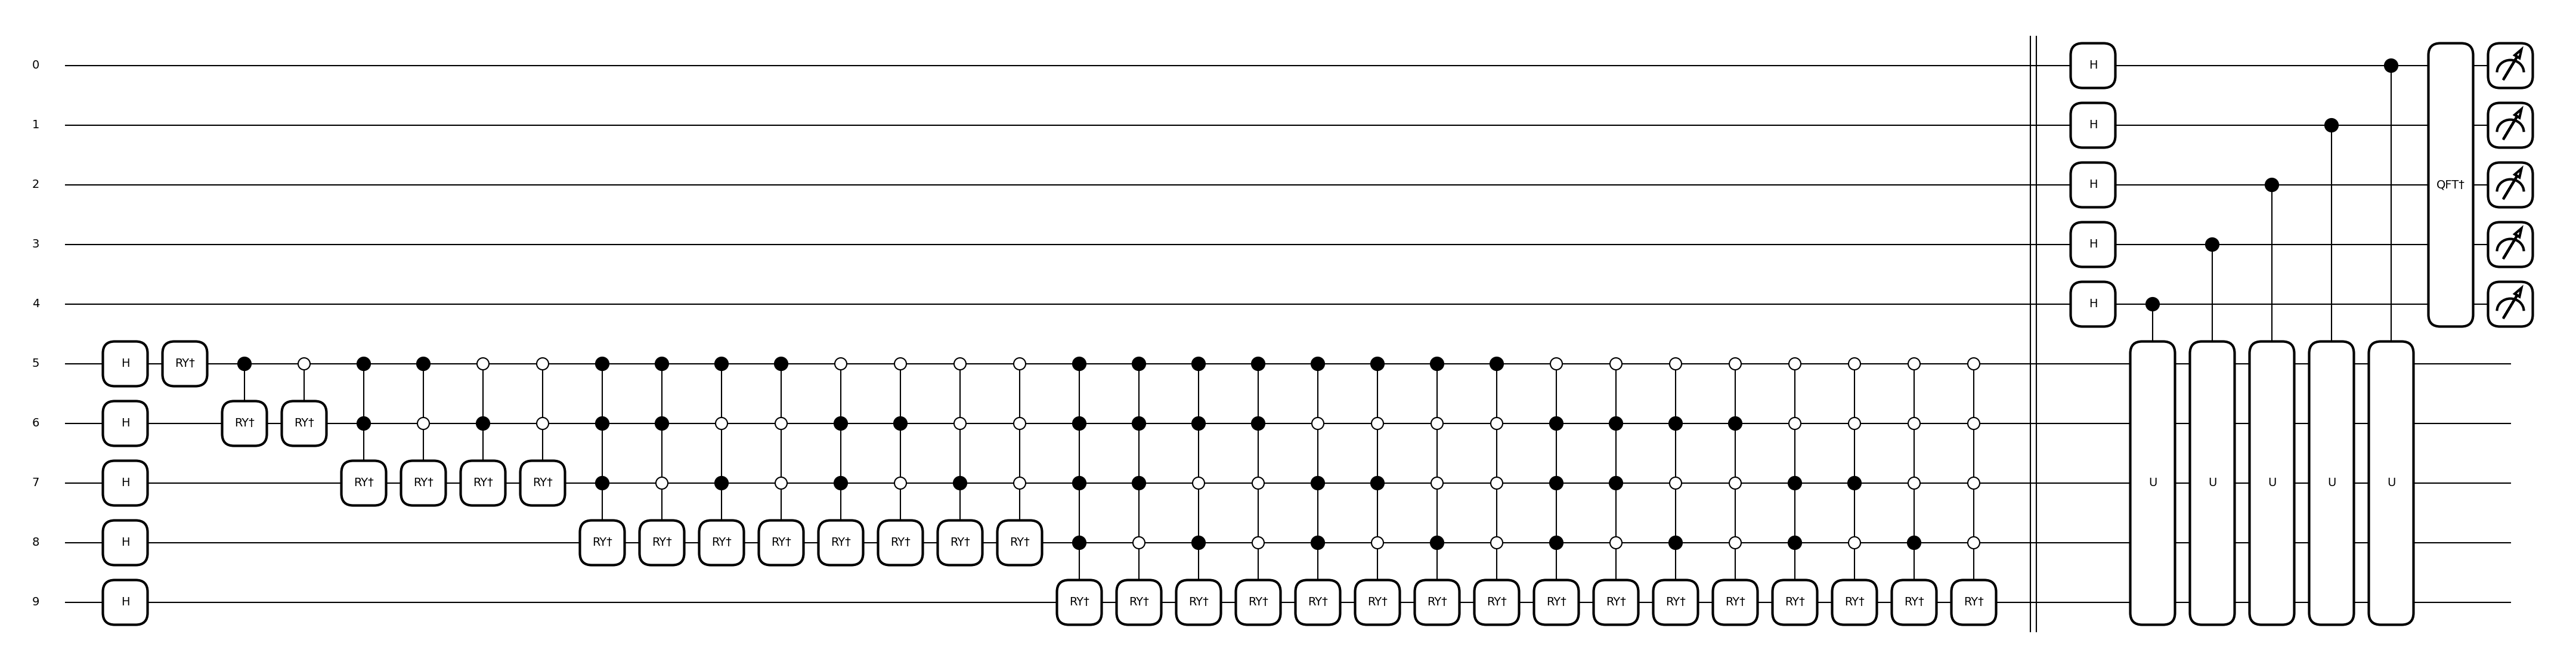

In [10]:
c = qml.QNode(circuit2,dev)
theta = np.random.uniform(0,np.pi,size=2**QQubits-1)
theta_2  = np.zeros_like(theta)
print(qml.draw_mpl(c)(theta_2, Img_O[0]))

In [11]:
print(c(theta_2, Img_O[0]))

0.010447079607649542


In [71]:
Img_O[:2].shape

(2, 32, 32)

In [59]:
theta = np.random.uniform(0,np.pi,size=2**QQubits-1)


In [60]:
theta

tensor([0.69269115, 0.57075716, 0.84231861, 0.80826979, 0.63650707,
        2.03427721, 1.82716872, 2.16412159, 1.84492431, 1.68640932,
        1.78951041, 2.57969735, 2.87297606, 1.93101573, 2.20503105,
        1.92071903, 0.23616546, 0.67666725, 0.23710991, 1.96830617,
        2.02779502, 0.90519468, 0.69126094, 1.9378074 , 0.43431261,
        1.74697108, 0.14254836, 0.48651829, 3.09568054, 0.64300718,
        0.6343304 ], requires_grad=True)